# A spin-echo EPI, and the one thing that differs

[`../gre_epi_2d/01_build.ipynb`](../gre_epi_2d/01_build.ipynb) built the readout and every number
in it. A spin-echo EPI is **the same `EPI2D`, played after a refocusing pulse**, which is the whole
argument for `readout/` being a leaf: the module holds no RF, knows nothing about slices, and
cannot tell a gradient echo from a spin echo.

One difference, and it is a *placement*:

> `prephase=False`, and both dephasers move to **before** the refocusing pulse, carrying the sign
> the conjugation will flip: `+area_to_echo_per_m` on the readout axis and `-k_blip_per_m(line0)`
> on the blip axis.

They then cost **no echo time at all** — the interval before the pulse already exists and was
empty. It is the same trick `CartesianLine(prephase=False)` is for in
[`../fse_2d/`](../fse_2d/01_build.ipynb), and [`../se_2d/`](../se_2d/01_build.ipynb) §4 already
argues that a sign error here is invisible: every waveform is legal, and against a symmetric
phantom the image still looks like an image. So it is asserted through `sc.kspace`, which is the
only oracle here that models the conjugation.

The second thing worth a section is that **TE is now two numbers.** The gradient echo lands on the
ADC raster and the spin echo on the gradient raster, they cannot be made equal, and the honest
thing is to print the gap.

**Output:** four `.seq` files and `seq/se_epi_2d_nominal.npz`. **Needs nothing but `seqcraft`.**

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)
MATRIX = (128, 128)
THICKNESS_MM = 5.0
DWELL_S = 2.5e-6
OVERSAMPLING = 2
EXCITE_DURATION_S = 2.0e-3
REFOCUS_DURATION_S = 3.0e-3
REFOCUS_FACTOR = 1.25            # the 180 selects a thicker slab than the 90
CRUSH_CYCLES_SLICE = 4.0
SPOIL_CYCLES = 4.0
TE_S = 100e-3                    # section 2 measures the shortest this shot reaches
TR_S = 1.0
SHOTS = (1, 2, 4)                # the segmentations section 3 tabulates and section 5 of `02` images
DUMMY_SHOTS = 2                  # every acquisition's run-in, so all of them start from one state

NX, NY = MATRIX
CENTER_LINE = NY // 2
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def compiled(tree, name='probe', definitions=None):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        seq = sc.compile(tree, opts, name=name, definitions=definitions)
    return seq, [str(w.message) for w in caught]


def gradient_kinds(seq, axis):
    return sorted({getattr(g, 'type', '?') for i in range(1, len(seq.block_events) + 1)
                   for g in (getattr(seq.get_block(i), axis, None),) if g is not None})


epi = sc.modules.EPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                       oversampling=OVERSAMPLING, prephase=False)

print(f'the same readout: {epi.num_samples} samples, {epi.echo_spacing_s * 1e6:.0f} us echo '
      f'spacing, {epi.bandwidth_hz_px:.0f} Hz/px')
print('prephase=False, so the module\'s block starts at the first lobe and the caller owes it')
print(f'  {epi.area_to_echo_per_m:8.2f} 1/m on {epi.axis}  (area_to_echo_per_m)')
print(f'  {epi.k_blip_per_m(0):8.2f} 1/m on {epi.blip_axis} for line 0  (k_blip_per_m)')

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


the same readout: 256 samples, 700 us echo spacing, 1562 Hz/px
prephase=False, so the module's block starts at the first lobe and the caller owes it
    295.60 1/m on x  (area_to_echo_per_m)
   -290.91 1/m on y for line 0  (k_blip_per_m)


---
## 1. `SEEPI2D`

Everything except the dephaser placement is [`../gre_epi_2d/`](../gre_epi_2d/01_build.ipynb)'s
kernel with a refocusing pulse dropped into the interval that was already there.

| | |
|---|---|
| **TE is symmetric about the refocusing centre** | so `min_te_s` is **twice** the longer of the two halves: excitation centre → pulse centre, and pulse centre → the `k = 0` sample of `center_echo` |
| **the pulse is placed with `Raster.nearest`, not `ceil`** | the residual is *doubled* on its way to the spin echo, so rounding one way costs twice what it looks like |
| **the crusher pair is `Refocusing`'s own** | both crushers straddle its own pulse, so it balances them itself. The two dephasers before it are not crushers and are not its business |

`Refocusing` selects a slab 1.25× the excitation's, for [`../se_2d/`](../se_2d/01_build.ipynb)'s
reason: a refocusing profile's edges are worse than an excitation's, and a slice refocused only in
its middle loses its edges twice per echo.

In [2]:
class SEEPI2D(sc.Module):
    """A spin-echo EPI.  One difference from the gradient echo, and it is a placement."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, echoes, center_echo,
                 flip_deg=90.0, refocus_flip_deg=180.0, te_s=None, tr_s=None, dwell_s=None,
                 bandwidth_hz_px=None, partial_fourier=1.0, oversampling=2, ramp_sampling=True,
                 blip_lines=1, navigator_echoes=0, excitation_duration_s=2.0e-3,
                 refocus_duration_s=3.0e-3, refocus_thickness_factor=1.25,
                 crush_cycles_slice=4.0, spoil_cycles_per_voxel=4.0, tag=None):
        super().__init__(opts=opts, tag=tag)
        self.raster = sc.Raster(opts.grad_raster_time)
        self.block_raster = sc.Raster(opts.block_duration_raster)
        self.fov_mm = (float(fov_mm[0]), float(fov_mm[1]))
        self.matrix = (int(matrix[0]), int(matrix[1]))
        self.thickness_mm = float(thickness_mm)
        self.echoes, self.center_echo = int(echoes), int(center_echo)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        self.refoc = sc.modules.Refocusing(
            opts=opts, thickness_mm=self.thickness_mm * refocus_thickness_factor,
            flip_deg=refocus_flip_deg, duration_s=refocus_duration_s,
            crush_cycles_per_voxel=crush_cycles_slice, crush_voxel_mm=self.thickness_mm)
        self.epi = sc.modules.EPI2D(
            opts=opts, fov_mm=self.fov_mm, matrix=self.matrix, dwell_s=dwell_s,
            bandwidth_hz_px=bandwidth_hz_px, partial_fourier=partial_fourier,
            oversampling=oversampling, ramp_sampling=ramp_sampling, blip_lines=blip_lines,
            navigator_echoes=navigator_echoes, prephase=False)
        self._probe_train = self.epi(lines=range(self.echoes))

        # A refocusing pulse maps k to -k, so a dephaser placed *before* it carries the opposite
        # sign of the one that would follow it.  The blip axis is designed for the largest line
        # the table might start on and scaled per shot, so the window does not move with the table.
        max_deph_y = max(abs(self.epi.k_blip_per_m(0)),
                         abs(self.epi.k_blip_per_m(self.matrix[1] - 1)))
        self.deph_s = float(self.raster.ceil(max(
            float(pp.calc_duration(pp.make_trapezoid('x', area=self.epi.area_to_echo_per_m,
                                                     system=opts))),
            float(pp.calc_duration(pp.make_trapezoid('y', area=max_deph_y, system=opts))),
            self.exc.rephaser_duration_s)))
        self._deph_x = pp.make_trapezoid('x', area=self.epi.area_to_echo_per_m,
                                         duration=self.deph_s, system=opts)
        self._deph_y = pp.make_trapezoid('y', area=max_deph_y, duration=self.deph_s, system=opts)
        self._deph_start_s = float(self.raster.ceil(
            max(self.exc.time_to_rephaser(), float(pp.calc_duration(self.exc.rf)))))

        # TE is symmetric about the refocusing centre, so the minimum is twice the longer half.
        self.min_te_s = 2 * float(self.raster.ceil(max(
            self._deph_start_s + self.deph_s + self.refoc.time_to_center()
            - self.exc.time_to_center(),
            self.refoc().duration - self.refoc.time_to_center()
            + self.epi.time_to_echo(self.center_echo))))
        target_te_s = self.min_te_s + fill_s(self.raster, te_s, self.min_te_s)
        self._train_start_s = float(self.raster.ceil(
            self.exc.time_to_center() + target_te_s - self.epi.time_to_echo(self.center_echo)))
        self.te_s = (self._train_start_s + self.epi.time_to_echo(self.center_echo)
                     - self.exc.time_to_center())
        # Nearest, not ceil: the residual is doubled on its way to the spin echo.
        self._refoc_start_s = float(self.raster.nearest(
            self.exc.time_to_center() + self.te_s / 2 - self.refoc.time_to_center()))
        self.spin_echo_s = 2 * (self._refoc_start_s + self.refoc.time_to_center()
                                - self.exc.time_to_center())

        self.spoil_area, self.tail_s = tail_design(
            opts, spoil_cycles_per_voxel, self.fov_mm, self.matrix, self.thickness_mm, self.epi,
            self._probe_train)
        self.shot_s = self._train_start_s + self._probe_train.duration + self.tail_s
        self.tr_s = tr_of(self.block_raster, tr_s, self.shot_s)

    @property
    def center_line(self):
        return self.epi.center_line

    @property
    def min_tr_s(self):
        return float(self.block_raster.ceil(self.shot_s))

    def build(self, *, lines, acquire=True, segment=None, reference=None):
        table = checked(self, lines)
        train = self.epi(lines=table, acquire=acquire, segment=segment, reference=reference)
        scale = -self.epi.k_blip_per_m(table[0]) / float(self._deph_y.area)
        out = sc.LogicBlock().add([
            # Excite about +y and refocus about +x: ninety degrees apart is the fixed point of the
            # map a refocusing pulse applies to transverse phase; the receiver stays at 0.
            [0.0, self.exc(phase_deg=90.0)],
            [self._deph_start_s, self._deph_x,
             sc.events.derive(pp.scale_grad(self._deph_y, scale))],
            [self._refoc_start_s, self.refoc(phase_deg=0.0)],
            [self._train_start_s, train],
        ])
        add_tail(self, out, train, self._train_start_s)
        return out


def fill_s(raster, wanted, floor_s):
    if wanted is None:
        return 0.0
    if float(wanted) < floor_s - 1e-12:
        raise sc.ConfigurationError(
            f'te_s = {float(wanted) * 1e3:.3f} ms is shorter than the {floor_s * 1e3:.3f} ms this '
            f'shot can achieve.')
    return float(raster.ceil(float(wanted) - floor_s))


def tr_of(block_raster, wanted, shot_s):
    if wanted is None:
        return float(block_raster.ceil(shot_s))
    if float(wanted) < float(block_raster.ceil(shot_s)) - 1e-12:
        raise sc.ConfigurationError(
            f'tr_s = {float(wanted) * 1e3:.3f} ms is shorter than the '
            f'{block_raster.ceil(shot_s) * 1e3:.3f} ms one shot occupies.')
    return float(block_raster.ceil(float(wanted)))


def tail_design(opts, cycles, fov_mm, matrix, thickness_mm, epi, probe_train):
    """The spoiler area per axis, and the one duration all three fit in, for the *worst* table."""
    voxel = {'x': fov_mm[0] / matrix[0], 'y': fov_mm[1] / matrix[1], 'z': thickness_mm}
    area = {axis: cycles / (voxel[axis] / 1e3) for axis in ('x', 'y', 'z')}
    measured = sc.moments(probe_train, order=0)
    worst = {'x': abs(measured.get('x', 0.0)),
             'y': max(abs(epi.k_blip_per_m(0)), abs(epi.k_blip_per_m(matrix[1] - 1))),
             'z': abs(measured.get('z', 0.0))}
    duration_s = max(float(pp.calc_duration(pp.make_trapezoid(
        axis, area=area[axis] + worst[axis], system=opts))) for axis in ('x', 'y', 'z'))
    return area, float(sc.Raster(opts.grad_raster_time).ceil(duration_s))


def add_tail(kernel, out, train, train_start_s):
    """One gradient per axis, spoiling *and* rewinding whatever the table left behind."""
    rewind = sc.moments(train, order=0)
    for axis, area in kernel.spoil_area.items():
        out.add(train_start_s + train.duration,
                pp.make_trapezoid(axis, area=area - rewind.get(axis, 0.0),
                                  duration=kernel.tail_s, system=kernel.opts))
    fill = float(kernel.block_raster.ceil(kernel.tr_s - kernel.shot_s))
    if fill > 1e-9:
        out.add(kernel.shot_s, pp.make_delay(fill))


def checked(kernel, lines):
    table = [int(v) for v in lines]
    if len(table) > kernel.echoes:
        raise sc.ConfigurationError(
            f'this shot has {len(table)} lines and the timing was built for at most '
            f'{kernel.echoes}.')
    if kernel.center_line in table and table.index(kernel.center_line) != kernel.center_echo:
        raise sc.ConfigurationError(
            f'this shot acquires the centre line at echo {table.index(kernel.center_line)}, not '
            f'at the center_echo={kernel.center_echo} the echo time was placed against.')
    return table


kernel = SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                 dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                 center_echo=CENTER_LINE, te_s=TE_S, tr_s=TR_S,
                 excitation_duration_s=EXCITE_DURATION_S, refocus_duration_s=REFOCUS_DURATION_S,
                 refocus_thickness_factor=REFOCUS_FACTOR, crush_cycles_slice=CRUSH_CYCLES_SLICE,
                 spoil_cycles_per_voxel=SPOIL_CYCLES)
lines = list(range(NY))

print(f'dephaser window {kernel.deph_s * 1e6:.0f} us, and it costs no echo time: the interval')
print('before the refocusing pulse already existed and was empty.')
print(f'min TE {kernel.min_te_s * 1e3:.3f} ms   requested {TE_S * 1e3:.0f} ms   '
      f'reports {kernel.te_s * 1e3:.3f} ms')
print(f'shot {kernel.shot_s * 1e3:.2f} ms, TR {kernel.tr_s * 1e3:.0f} ms')

dephaser window 470 us, and it costs no echo time: the interval
before the refocusing pulse already existed and was empty.
min TE 94.920 ms   requested 100 ms   reports 100.001 ms
shot 147.32 ms, TR 1000 ms


### The sign, asserted through the conjugation

`sc.kspace` applies pypulseq's own sign flip at `use='refocusing'`, so a **signed** `k` at the
echo *sample* is a statement about the physics rather than about this notebook's algebra. Signed,
because `|k|` is symmetric and a k-space *extent* check passes on a mirrored image.

The wrong sign on either dephaser is a whole readout's worth of `k`, every waveform stays legal,
and the compiler has nothing to say about it.

In [3]:
shot = kernel(lines=lines)
seq, notes = compiled(sc.LogicBlock('shot').add(0.0, shot), 'se_epi_2d')
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    k = sc.kspace(sc.LogicBlock('shot').add(0.0, shot), opts)

ka = k['k_adc'].reshape(3, NY, kernel.epi.num_samples)
t_adc = k['t_adc'].reshape(NY, kernel.epi.num_samples)
sample = kernel.epi.echo_sample(kernel.center_echo)
t_exc = float(k['t_excitation'][0])
want_ky = (np.asarray(lines) - CENTER_LINE) * DK_Y

print(f'|kx| at the centre echo   {abs(ka[0][kernel.center_echo, sample]):.2e} 1/m   '
      f'(dk = {DK_X:.3f})')
print(f'|ky| at the centre echo   {abs(ka[1][kernel.center_echo, sample]):.2e} 1/m')
print(f'ky per line, worst        {np.abs(ka[1] - want_ky[:, None]).max():.2e} 1/m')
print(f'kx at every echo sample   '
      f'{max(abs(ka[0][n, kernel.epi.echo_sample(n)]) for n in range(NY)):.2e} 1/m')
print(f'{len(seq.block_events)} blocks; every gx a {gradient_kinds(seq, "gx")}')

# The same three tables, with one dephaser sign flipped, to say what the check is worth.
print(f'\n{"dephaser signs":30s} {"|kx| at centre echo":>20s} {"|ky|":>12s}')
for label, sign_x, sign_y in (('+area_x, -k_blip_y (as built)', +1, -1),
                              ('-area_x, -k_blip_y', -1, -1),
                              ('+area_x, +k_blip_y', +1, +1)):
    probe = sc.LogicBlock().add([
        [0.0, kernel.exc(phase_deg=90.0)],
        [kernel._deph_start_s,
         sc.events.derive(pp.scale_grad(kernel._deph_x, sign_x)),
         sc.events.derive(pp.scale_grad(
             kernel._deph_y, sign_y * kernel.epi.k_blip_per_m(lines[0])
             / float(kernel._deph_y.area)))],
        [kernel._refoc_start_s, kernel.refoc(phase_deg=0.0)],
        [kernel._train_start_s, kernel.epi(lines=lines)],
    ])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', sc.SeqCraftWarning)
        probe_k = sc.kspace(sc.LogicBlock('p').add(0.0, probe), opts)['k_adc']
    probe_k = probe_k.reshape(3, NY, kernel.epi.num_samples)
    print(f'{label:30s} {abs(probe_k[0][kernel.center_echo, sample]):16.2e} 1/m '
          f'{abs(probe_k[1][kernel.center_echo, sample]):8.1f} 1/m')
print('Both wrong signs are a legal sequence that acquires a different part of k-space, and')
print('against a symmetric phantom both still look like an image.')

|kx| at the centre echo   4.11e-07 1/m   (dk = 4.545)
|ky| at the centre echo   4.04e-07 1/m
ky per line, worst        4.04e-07 1/m
kx at every echo sample   4.11e-07 1/m
135 blocks; every gx a ['trap']

dephaser signs                  |kx| at centre echo         |ky|
+area_x, -k_blip_y (as built)          4.11e-07 1/m      0.0 1/m


-area_x, -k_blip_y                     5.91e+02 1/m      0.0 1/m
+area_x, +k_blip_y                     4.11e-07 1/m    581.8 1/m
Both wrong signs are a legal sequence that acquires a different part of k-space, and
against a symmetric phantom both still look like an image.


## 2. TE is two numbers, and they cannot be made equal

The **gradient** echo is an ADC sample, so it lives on the ADC raster. The **spin** echo is twice
the interval from the excitation's effective centre to the refocusing pulse's, so it lives on the
gradient raster. Ten to one, and no placement makes both exact.

That is why the refocusing pulse is placed with `Raster.nearest` rather than `Raster.ceil`: the
residual is **doubled** on its way to the spin echo, so rounding always upward costs twice what it
looks like it costs.

In [4]:
print(f'{"requested TE":>13s} {"gradient echo":>14s} {"spin echo":>11s} {"apart":>9s} '
      f'{"nearest vs ceil":>16s}')
for wanted in (None, 100e-3, 130e-3, 160e-3):
    made = SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                   dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                   center_echo=CENTER_LINE, te_s=wanted, tr_s=TR_S)
    ceil_start = float(grad_raster.ceil(made.exc.time_to_center() + made.te_s / 2
                                        - made.refoc.time_to_center()))
    if_ceil = 2 * (ceil_start + made.refoc.time_to_center() - made.exc.time_to_center())
    label = 'minimum' if wanted is None else f'{wanted * 1e3:.0f} ms'
    print(f'{label:>13s} {made.te_s * 1e3:13.3f}m {made.spin_echo_s * 1e3:10.3f}m '
          f'{abs(made.spin_echo_s - made.te_s) * 1e6:8.2f}u '
          f'{abs(if_ceil - made.te_s) * 1e6:15.2f}u')
print('\nThe last column is what ceil would have cost instead.  Both are small; one is smaller,')
print('and it is the free one.')

 requested TE  gradient echo   spin echo     apart  nearest vs ceil
      minimum        94.921m     94.920m     1.25u           18.75u


       100 ms       100.001m    100.000m     1.25u           18.75u
       130 ms       130.001m    130.000m     1.25u           18.75u
       160 ms       160.001m    160.000m     1.25u           18.75u

The last column is what ceil would have cost instead.  Both are small; one is smaller,
and it is the free one.


## 3. What a shorter train is for here, and how to get one without unfolding

A refocusing pulse refocuses at **one instant**. It recovers the T2′ dephasing accumulated up to
the echo and does nothing at all to the phase that accumulates *between* echoes — so it fixes the
decay across the train and leaves the geometric distortion exactly where it was.

> **Only a shorter train shortens the distortion.** Nothing about the 180 does.

There are two ways to shorten it, and they buy the identical train:

| | |
|---|---|
| **accelerate** | acquire every `R`-th line in one shot, and unfold the rest. Needs a calibration band, needs a GRAPPA fit, and leaves whatever the fit cannot explain in the image |
| **segment** | acquire every `S`-th line in each of `S` shots, and simply *interleave* them. No unfolding, no calibration, no residual — the data is fully sampled. It costs `S` TRs |

A spin echo is where the second one is affordable, because a spin-echo TR is long for reasons
that have nothing to do with EPI: 100 ms of TE inside a 1 s TR leaves the magnetisation most of
a second to recover whether you use it or not. So this notebook segments, and
[`../gre_epi_2d/`](../gre_epi_2d/01_build.ipynb) is where acceleration is measured.

The table below holds **TE at 100 ms across all three**, so its last column is a clean statement
about what the train length does and does not do to a spin echo.

In [5]:
def shot_tables(shots):
    """`shots` interleaved tables that between them cover every line, centre line anchored."""
    return [list(range(CENTER_LINE % shots + s, NY, shots)) for s in range(shots)]


def segmented(shots, **kwargs):
    """The kernel one shot of an `shots`-way segmented acquisition needs."""
    table = shot_tables(shots)[0]
    return SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                   dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=len(table),
                   center_echo=table.index(CENTER_LINE), blip_lines=shots,
                   te_s=TE_S, tr_s=TR_S, **kwargs)


print(f'{"shots":>6s} {"esp":>7s} {"lines/shot":>11s} {"train":>9s} {"TE":>9s} {"min TE":>9s} '
      f'{"shift at 60 Hz":>15s} {"scan":>7s}')
for _s in SHOTS:
    made = segmented(_s)
    train = len(shot_tables(_s)[0]) * made.epi.echo_spacing_s
    print(f'{_s:6d} {made.epi.echo_spacing_s * 1e6:6.0f}u '
          f'{len(shot_tables(_s)[0]):11d} {train * 1e3:8.2f}m '
          f'{made.te_s * 1e3:8.3f}m {made.min_te_s * 1e3:8.3f}m {60.0 * train:14.2f}px '
          f'{_s * TR_S:6.0f}s')
print()
print(f'Every table above is anchored on the centre line, so all {len(SHOTS)} acquisitions place '
      f'k = 0 at')
print('their own centre echo and the echo time means the same thing in each.  Note the *minimum*')
print('TE column: it falls with the segmentation too, because half of TE is the time from the')
print('refocusing pulse to the centre of k-space and a shorter shot reaches that echo sooner.')
print(f'None of them use it -- all three are written at {TE_S * 1e3:.0f} ms -- which is the point.')

 shots     esp  lines/shot     train        TE    min TE  shift at 60 Hz    scan
     1    700u         128    89.60m  100.001m   94.920m           5.38px      1s
     2    720u          64    46.08m  100.001m   51.420m           2.76px      2s
     4    740u          32    23.68m  100.001m   29.040m           1.42px      4s

Every table above is anchored on the centre line, so all 3 acquisitions place k = 0 at
their own centre echo and the echo time means the same thing in each.  Note the *minimum*
TE column: it falls with the segmentation too, because half of TE is the time from the
refocusing pulse to the centre of k-space and a shorter shot reaches that echo sooner.
None of them use it -- all three are written at 100 ms -- which is the point.


## 4. The refusals

In [6]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what}\n  {str(error).splitlines()[0]}\n')
    else:
        raise AssertionError(f'{what} was not refused')


refused('a TE shorter than the two halves allow',
        lambda: SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                        dwell_s=DWELL_S, echoes=NY, center_echo=CENTER_LINE, te_s=10e-3))
refused('a TR shorter than one shot',
        lambda: SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                        dwell_s=DWELL_S, echoes=NY, center_echo=CENTER_LINE, tr_s=10e-3))
refused('a shot whose centre line is not where TE was placed',
        lambda: kernel(lines=lines[::-1]))
refused('a 180 short enough to be over max_b1, which sc.compile would not catch',
        lambda: sc.modules.Refocusing(opts=opts, thickness_mm=6.25, duration_s=1e-3))

a TE shorter than the two halves allow
  te_s = 10.000 ms is shorter than the 94.920 ms this shot can achieve.

a TR shorter than one shot
  tr_s = 10.000 ms is shorter than the 142.240 ms one shot occupies.

a shot whose centre line is not where TE was placed
  this shot acquires the centre line at echo 63, not at the center_echo=64 the echo time was placed against.

a 180 short enough to be over max_b1, which sc.compile would not catch
  a 1 ms 180 degree sinc pulse peaks at 260 % of max_b1.



---
## The files

Four, and **every one of them at TE = 100 ms**: a single shot, a partial echo, and the same 128
lines split across two and four interleaved shots.

Each acquisition gets the same **two-shot run-in**, for the reason
[`../gre_epi_2d/01`](../gre_epi_2d/01_build.ipynb) §8 gives and measures. A segmented acquisition
puts consecutive `ky` lines in *different* shots, so any shot-to-shot difference in signal is a
modulation of period `S` along `ky` — a replica of the object at `Ny/S`, which reads as an
under-sampling artefact and is not one. The run-in is what makes every shot see the same
magnetisation, and giving the single-shot files the same one is what makes the four images
comparable rather than four different steady states.

A 90° excitation leaves `Mz = 0` whatever it started from, so one dummy would do at this TR; the
transverse carry-over the crushers and the spoiler have to finish off is `exp(-TR/T2)`, which at
TR = 1 s is 4e-6. Two is the cheap margin, not a measurement.

In [7]:
def write(name, tree, made, note):
    definitions = {
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'kSpaceCenterLine': CENTER_LINE,
        'TE': made.te_s, 'TR': made.tr_s,
        'ReceiverBandwidth': made.epi.bandwidth_hz_px,
    }
    seq, _ = compiled(tree, name, definitions)
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    print(f'-> {name + ".seq":26s} {len(seq.block_events):5d} blocks  '
          f'{seq.duration()[0] * 1e3:8.1f} ms  TE {made.te_s * 1e3:6.2f} ms  {note}')


def acquisition(name, made, tables, note):
    """`len(tables)` interleaved shots behind a run-in, written as one file."""
    tree, played = sc.LogicBlock(name), [tables[0]] * DUMMY_SHOTS + list(tables)
    for n, table in enumerate(played):
        acquire = n >= DUMMY_SHOTS
        tree.add(n * made.tr_s, made(lines=table, acquire=acquire,
                                     segment=(n - DUMMY_SHOTS) if acquire else None))
    write(name, tree, made, note)
    return made


kernel_pf = SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                    dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=NY,
                    center_echo=CENTER_LINE, partial_fourier=0.75, te_s=TE_S, tr_s=TR_S)

made_for = {1: kernel}
acquisition('se_epi_full', kernel, [lines], '1 shot of 128 lines')
acquisition('se_epi_pf075', kernel_pf, [lines], '1 shot, partial echo 0.75')
for _s in SHOTS[1:]:
    made_for[_s] = acquisition(f'se_epi_{_s}shot', segmented(_s), shot_tables(_s),
                               f'{_s} interleaved shots of {NY // _s} lines')

# The invariant, checked rather than intended.  What each kernel *achieves* is the request rounded
# onto the gradient raster, and the remainder differs between them because their minimum echo
# times do -- so the invariant is agreement to a raster, not equality.
_te = {'se_epi_full': kernel.te_s, 'se_epi_pf075': kernel_pf.te_s,
       **{f'se_epi_{s}shot': made_for[s].te_s for s in SHOTS[1:]}}
spread_s = max(_te.values()) - min(_te.values())
print()
for _name in sorted(_te):
    print(f'   {_name:16s} TE {_te[_name] * 1e3:8.4f} ms')
print(f'\nrequested {TE_S * 1e3:.0f} ms, spread {spread_s * 1e6:.2f} us = '
      f'{spread_s / opts.grad_raster_time:.2f} gradient rasters = {spread_s / TE_S:.3%} of TE,')
print('so a difference between two of the pictures in `02` is the acquisition and not the')
print('contrast -- which for a spin echo at one T2 of echo time is the whole ball game.')
assert spread_s <= opts.grad_raster_time + 1e-12

-> se_epi_full.seq              405 blocks    3000.0 ms  TE 100.00 ms  1 shot of 128 lines


-> se_epi_pf075.seq             405 blocks    3000.0 ms  TE 100.00 ms  1 shot, partial echo 0.75


-> se_epi_2shot.seq             284 blocks    4000.0 ms  TE 100.00 ms  2 interleaved shots of 64 lines


-> se_epi_4shot.seq             234 blocks    6000.0 ms  TE 100.00 ms  4 interleaved shots of 32 lines

   se_epi_2shot     TE 100.0012 ms
   se_epi_4shot     TE 100.0012 ms
   se_epi_full      TE 100.0012 ms
   se_epi_pf075     TE 100.0012 ms

requested 100 ms, spread 0.00 us = 0.00 gradient rasters = 0.000% of TE,
so a difference between two of the pictures in `02` is the acquisition and not the
contrast -- which for a spin echo at one T2 of echo time is the whole ball game.


In [8]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    nominal = sc.kspace(sc.LogicBlock('n').add(0.0, kernel(lines=lines)), opts)['k_adc']

np.savez(
    SEQ_DIR / 'se_epi_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, lines=np.array(lines),
    k=nominal.reshape(3, NY, kernel.epi.num_samples),
    k_read_per_m=kernel.epi.k_read_per_m,
    k_read_per_m_pf=kernel_pf.epi.k_read_per_m,
    num_samples=kernel.epi.num_samples, pre_echo_samples=kernel.epi.pre_echo_samples,
    num_samples_pf=kernel_pf.epi.num_samples, pre_echo_samples_pf=kernel_pf.epi.pre_echo_samples,
    oversampling=OVERSAMPLING, dwell_s=kernel.epi.dwell_s,
    bandwidth_hz_px=kernel.epi.bandwidth_hz_px, echo_spacing_s=kernel.epi.echo_spacing_s,
    echo_spacing_s_pf=kernel_pf.epi.echo_spacing_s,
    te_s=kernel.te_s, te_s_pf=kernel_pf.te_s, spin_echo_s=kernel.spin_echo_s, tr_s=kernel.tr_s,
    min_te_s=kernel.min_te_s, min_te_s_pf=kernel_pf.min_te_s, excite_duration_s=EXCITE_DURATION_S,
    refocus_duration_s=REFOCUS_DURATION_S, refocus_factor=REFOCUS_FACTOR,
    crush_cycles_slice=CRUSH_CYCLES_SLICE, spoil_cycles=SPOIL_CYCLES,
    shots=np.array(SHOTS), dummy_shots=DUMMY_SHOTS,
    **{f'tables_{s}': np.array(shot_tables(s)) for s in SHOTS},
    **{f'esp_{s}': made_for[s].epi.echo_spacing_s for s in SHOTS},
)
print(f'-> {SEQ_DIR / "se_epi_2d_nominal.npz"}')

-> seq\se_epi_2d_nominal.npz


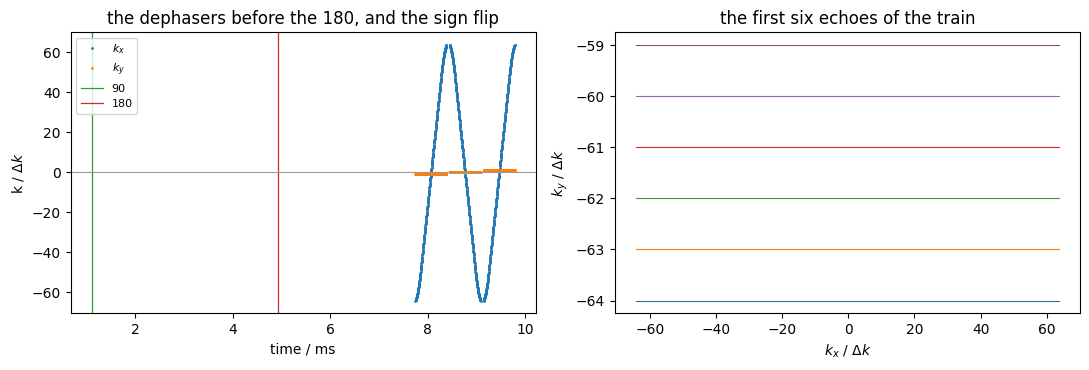

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
# Three echoes rather than 64, so the dephasers and the sign flip are visible at all.
short = SEEPI2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                dwell_s=DWELL_S, oversampling=OVERSAMPLING, echoes=3, center_echo=1, tr_s=TR_S)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    t = sc.kspace(sc.LogicBlock('one').add(
        0.0, short(lines=[CENTER_LINE - 1, CENTER_LINE, CENTER_LINE + 1])), opts)
axes[0].plot(t['t_adc'] * 1e3, t['k_adc'][0] / DK_X, '.', ms=2, label='$k_x$')
axes[0].plot(t['t_adc'] * 1e3, t['k_adc'][1] / DK_Y, '.', ms=2, label='$k_y$')
axes[0].axvline(t['t_excitation'][0] * 1e3, color='C2', lw=0.9, label='90')
axes[0].axvline(t['t_refocusing'][0] * 1e3, color='C3', lw=0.9, label='180')
axes[0].axhline(0, color='0.6', lw=0.8)
axes[0].set(xlabel='time / ms', ylabel='k / $\\Delta k$',
            title='the dephasers before the 180, and the sign flip')
axes[0].legend(fontsize=8)

axes[1].plot(nominal.reshape(3, NY, -1)[0][:6].T / DK_X,
             nominal.reshape(3, NY, -1)[1][:6].T / DK_Y, lw=0.8)
axes[1].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$',
            title='the first six echoes of the train')
fig.tight_layout()

---
## What this notebook established

| | |
|---|---|
| **one readout, two sequences** | `EPI2D` is unchanged between here and [`../gre_epi_2d/`](../gre_epi_2d/01_build.ipynb). `readout/` holds no RF, so it cannot tell a gradient echo from a spin echo — which is the whole reason the folder rule is what it is |
| **`prephase=False`, and both dephasers before the pulse** | with the sign the conjugation will flip, and costing no echo time because the interval was already there |
| **the sign is asserted through `sc.kspace`** | the only oracle here that models the conjugation. Both wrong signs are legal sequences that acquire a different part of k-space |
| **TE is two numbers** | the gradient echo on the ADC raster and the spin echo on the gradient raster, a few microseconds apart, and the honest thing is to print the gap |
| **`Raster.nearest`, not `ceil`** | the residual is doubled on its way to the spin echo |
| **segmentation is not about scan time here** | a refocusing pulse refocuses at one instant, so it fixes the decay across the train and leaves the distortion. Only a shorter train touches that — and `S` interleaved shots buy the same short train an `R`-fold acceleration does, with no calibration, no unfolding and no residual |
| **one echo time across every file** | 100 ms, checked and printed. At one T2 of echo time a contrast difference between two panels would dwarf anything the acquisition does, so holding TE is what makes §5 of `02` a measurement |

[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) measures the claim
arithmetic cannot make — that this is a **T2** echo and not a T2\* one — and then the one most
readers expect to come out the other way: **a spin echo does not fix EPI distortion.**